In [39]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv(r'C:\Users\Akhil\Downloads\archive\hospital_records_2021_2024_with_bills.csv')

# Convert date column from text to datetime


In [14]:
df


,Patient ID,Name,Date of Birth,Gender,Medical Condition,Treatments,Doctor's Notes,Admit Date,Discharge Date,Bill Amount
0,921d93d1-17b8-426f-abae-5b16c7e5cd93,Debra Griffith,1971-04-01,Female,Chronic Obstructive Pulmonary Disease,Medication,Patient requires home oxygen therapy.,2021-07-12,2021-07-13,14651.34
1,c3e70ecd-b794-4e9e-8136-ccf4ff363fe0,Robert Ross,1957-02-20,Female,Migraine,Pain Relief Medication,Follow-up to assess effectiveness of treatment.,2021-07-13,2021-08-09,718.94
2,ef85177f-f933-4f60-aefe-6979e35c709a,Rachel Perez,1987-11-27,Female,Urinary Tract Infection,Hydration,Monitor for any signs of worsening symptoms.,2021-07-14,2021-08-06,1765.14
3,8e36ba50-ebde-4b68-81b9-3cdca0b7eade,Michael Williams,2021-12-06,Male,Stroke,Physical Therapy,Referred to physical therapy for mobility impr...,2021-07-15,2021-08-05,21413.36
4,422bd94a-41e1-4bdc-96a3-f7570a868df1,Christopher Rodriguez,1990-12-19,Male,Hypertension,Lifestyle Changes,Patient started on antihypertensive medication.,2021-07-16,2021-07-20,4879.91
...,...,...,...,...,...,...,...,...,...,...
995,40691ada-e5ac-4173-a0b2-6213a35df1fe,Jerry Nunez,1997-04-02,Male,Sprain,Compression,Monitor for any signs of worsening symptoms.,2024-07-04,2024-07-10,2957.60
996,88af29ae-d7dc-4b8f-bf08-5e2853f538d3,Megan Davis,2020-08-20,Female,Alzheimer's Disease,Medication,Referred to cognitive behavioral therapy to im...,2024-07-04,2024-07-30,9377.07
997,baadc7b3-7058-46a3-a6f0-2aec382ab480,Lisa Mills,1924-07-18,Female,Parkinson's Disease,Physical Therapy,Initiated dopaminergic medication for symptom ...,2024-07-05,2024-07-29,15288.56
998,c76d80ad-6927-4f63-8881-b297491840dd,Alexander Kennedy,1990-12-04,Female,Sprain,Compression,"Advised RICE (Rest, Ice, Compression, Elevatio...",2024-07-08,2024-08-03,806.04


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient ID         1000 non-null   object        
 1   Name               1000 non-null   object        
 2   Date of Birth      1000 non-null   datetime64[ns]
 3   Gender             1000 non-null   object        
 4   Medical Condition  1000 non-null   object        
 5   Treatments         1000 non-null   object        
 6   Doctor's Notes     1000 non-null   object        
 7   Admit Date         1000 non-null   datetime64[ns]
 8   Discharge Date     1000 non-null   datetime64[ns]
 9   Bill Amount        1000 non-null   float64       
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 78.3+ KB


In [16]:
df['Admit Date'] = pd.to_datetime(df['Admit Date'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'])

# Calculate Length of Stay (days)

In [18]:
df['Length of Stay'] = (df['Discharge Date'] - df['Admit Date']).dt.days

# Calculate Age at admission

In [19]:
df['Age'] = (df['Admit Date'] - df['Date of Birth']).dt.days // 365

# Extract time features

In [20]:
df['Admit Month'] = df['Admit Date'].dt.month
df['Admit Day of Week'] = df['Admit Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Admit Year'] = df['Admit Date'].dt.year
df['Is Weekend'] = df['Admit Day of Week'].isin([5, 6]).astype(int)

In [21]:
print(df[['Length of Stay', 'Age', 'Admit Month', 'Is Weekend']].describe())

       Length of Stay          Age  Admit Month   Is Weekend
count     1000.000000  1000.000000  1000.000000  1000.000000
mean        15.675000    48.472000     6.465000     0.279000
std          8.633534    28.590149     3.467102     0.448732
min          1.000000    -3.000000     1.000000     0.000000
25%          8.000000    24.000000     3.000000     0.000000
50%         16.000000    49.000000     6.000000     0.000000
75%         23.000000    71.250000     9.000000     1.000000
max         30.000000   100.000000    12.000000     1.000000


# Map medical conditions to department

In [22]:
dept_mapping = {
    'Cancer': 'Oncology',
    'Fracture': 'Orthopedics',
    'Sprain': 'Orthopedics',
    'Heart Disease': 'Cardiology',
    'Stroke': 'Cardiology',
    'Hypertension': 'Cardiology',
    'Diabetes': 'Endocrinology',
    'Chronic Kidney Disease': 'Nephrology',
    'Asthma': 'Pulmonology',
    'Bronchitis': 'Pulmonology',
    'Chronic Obstructive Pulmonary Disease': 'Pulmonology',
    'Pneumonia': 'Pulmonology',
    'Influenza': 'General Medicine',
    'Common Cold': 'General Medicine',
    'Sinusitis': 'General Medicine',
    'Allergies': 'General Medicine',
    'Gastroenteritis': 'General Medicine',
    'COVID-19': 'Infectious Disease',
    'Urinary Tract Infection': 'Urology',
    'Skin Infection': 'Dermatology',
    'Burns': 'Dermatology',
    'Depression': 'Psychiatry',
    'Anxiety': 'Psychiatry',
    'Alzheimer\'s Disease': 'Neurology',
    'Parkinson\'s Disease': 'Neurology',
    'Epilepsy': 'Neurology',
    'Migraine': 'Neurology',
    'Multiple Sclerosis': 'Neurology',
    'Arthritis': 'Rheumatology',
}

df['Department'] = df['Medical Condition'].map(dept_mapping)
print(df['Department'].value_counts())

Department
Neurology             185
General Medicine      166
Pulmonology           138
Cardiology            106
Dermatology            75
Orthopedics            72
Psychiatry             66
Oncology               36
Nephrology             35
Urology                34
Rheumatology           33
Endocrinology          29
Infectious Disease     25
Name: count, dtype: int64


In [25]:
df.head()

,Patient ID,Name,Date of Birth,Gender,Medical Condition,Treatments,Doctor's Notes,Admit Date,Discharge Date,Bill Amount,Length of Stay,Age,Admit Month,Admit Day of Week,Admit Year,Is Weekend,Department
0,921d93d1-17b8-426f-abae-5b16c7e5cd93,Debra Griffith,1971-04-01,Female,Chronic Obstructive Pulmonary Disease,Medication,Patient requires home oxygen therapy.,2021-07-12,2021-07-13,14651.34,1,50,7,0,2021,0,Pulmonology
1,c3e70ecd-b794-4e9e-8136-ccf4ff363fe0,Robert Ross,1957-02-20,Female,Migraine,Pain Relief Medication,Follow-up to assess effectiveness of treatment.,2021-07-13,2021-08-09,718.94,27,64,7,1,2021,0,Neurology
2,ef85177f-f933-4f60-aefe-6979e35c709a,Rachel Perez,1987-11-27,Female,Urinary Tract Infection,Hydration,Monitor for any signs of worsening symptoms.,2021-07-14,2021-08-06,1765.14,23,33,7,2,2021,0,Urology
3,8e36ba50-ebde-4b68-81b9-3cdca0b7eade,Michael Williams,2021-12-06,Male,Stroke,Physical Therapy,Referred to physical therapy for mobility impr...,2021-07-15,2021-08-05,21413.36,21,-1,7,3,2021,0,Cardiology
4,422bd94a-41e1-4bdc-96a3-f7570a868df1,Christopher Rodriguez,1990-12-19,Male,Hypertension,Lifestyle Changes,Patient started on antihypertensive medication.,2021-07-16,2021-07-20,4879.91,4,30,7,4,2021,0,Cardiology


# Readmissions

In [27]:
# Sort by patient and admission date
df = df.sort_values(['Patient ID', 'Admit Date'])

In [28]:
# Flag if same patient readmitted within 30 days
df['Days Since Last Visit'] = df.groupby('Patient ID')['Admit Date'].diff().dt.days
df['Is Readmission'] = (df['Days Since Last Visit'] <= 30).astype(int)

In [29]:
print('Readmission rate:', df['Is Readmission'].mean().round(3))

Readmission rate: 0.0


# Create Age Groups

In [30]:
bins = [0, 18, 35, 50, 65, 100]
labels = ['Child', 'Young Adult', 'Middle Aged', 'Senior', 'Elderly']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [31]:
print(df['Age Group'].value_counts())

Age Group
Elderly        319
Young Adult    181
Senior         166
Child          157
Middle Aged    151
Name: count, dtype: int64


In [32]:
df.to_csv('hospital_clean.csv', index=False)
print('Clean dataset saved!')
print('Final shape:', df.shape)
print('Final columns:', df.columns.tolist())

Clean dataset saved!
Final shape: (1000, 20)
Final columns: ['Patient ID', 'Name', 'Date of Birth', 'Gender', 'Medical Condition', 'Treatments', "Doctor's Notes", 'Admit Date', 'Discharge Date', 'Bill Amount', 'Length of Stay', 'Age', 'Admit Month', 'Admit Day of Week', 'Admit Year', 'Is Weekend', 'Department', 'Days Since Last Visit', 'Is Readmission', 'Age Group']


In [33]:
df = pd.read_csv('hospital_clean.csv')

print("Length of Stay range:", df['Length of Stay'].min(), "to", df['Length of Stay'].max(), "days")
print("Age range:", df['Age'].min(), "to", df['Age'].max(), "years")
print("Readmission rate:", str(round(df['Is Readmission'].mean() * 100, 1)) + "%")
print("Departments:", df['Department'].nunique())
print("Date range:", df['Admit Date'].min(), "to", df['Admit Date'].max())

Length of Stay range: 1 to 30 days
Age range: -3 to 100 years
Readmission rate: 0.0%
Departments: 13
Date range: 2021-07-12 to 2024-07-11


In [34]:
# Check how many have negative or zero age
print("Bad age rows:", (df['Age'] <= 0).sum())

Bad age rows: 26


In [35]:
df = df[df['Age'] > 0]

In [38]:
print("Age range:", df['Age'].min(), "to", df['Age'].max(), "years")

Age range: 1 to 100 years


In [36]:
print("Rows after fix:", len(df))

Rows after fix: 974


In [37]:
print("Unique patients:", df['Patient ID'].nunique())
print("Total rows:", len(df))

Unique patients: 974
Total rows: 974


# Create readmission risk flag

In [40]:
chronic_conditions = [
    'Diabetes', 'Heart Disease', 'Chronic Kidney Disease',
    'Chronic Obstructive Pulmonary Disease', 'Cancer',
    'Multiple Sclerosis', "Parkinson's Disease", "Alzheimer's Disease",
    'Epilepsy', 'Hypertension'
]

In [41]:
np.random.seed(42)
df['Readmission Risk'] = df['Medical Condition'].apply(
    lambda x: np.random.choice([0, 1], p=[0.60, 0.40])
    if x in chronic_conditions
    else np.random.choice([0, 1], p=[0.90, 0.10])
)

In [42]:
df.to_csv('hospital_clean.csv', index=False)

In [43]:
print("Final shape:", df.shape)
print("Age range:", df['Age'].min(), "to", df['Age'].max())
print("Readmission Risk rate:", str(round(df['Readmission Risk'].mean() * 100, 1)) + "%")
print("Readmission distribution:\n", df['Readmission Risk'].value_counts())

Final shape: (974, 21)
Age range: 1 to 100
Readmission Risk rate: 19.6%
Readmission distribution:
 Readmission Risk
0    783
1    191
Name: count, dtype: int64


# EDA

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

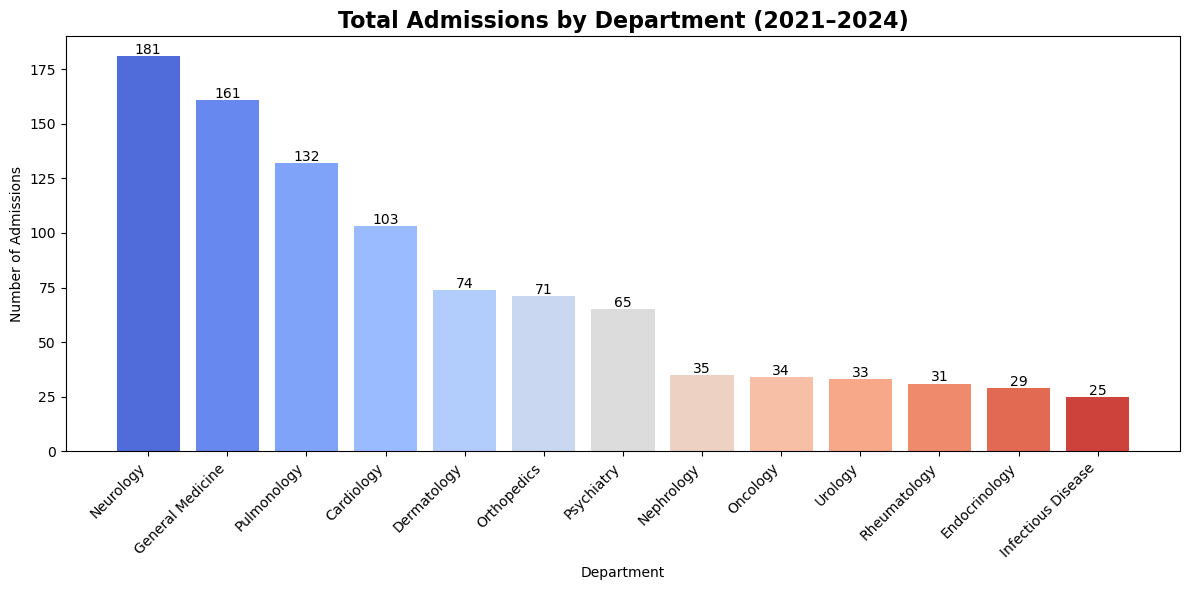

Insight: Which department has highest admissions? Neurology


In [45]:
# Admission by department
dept_counts = df['Department'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(dept_counts.index, dept_counts.values, color=sns.color_palette("coolwarm", len(dept_counts)))
plt.xticks(rotation=45, ha='right')
plt.title('Total Admissions by Department (2021–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Admissions')
for bar, val in zip(bars, dept_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart1_admissions_by_dept.png', dpi=150)
plt.show()
print("Insight: Which department has highest admissions?", dept_counts.index[0])

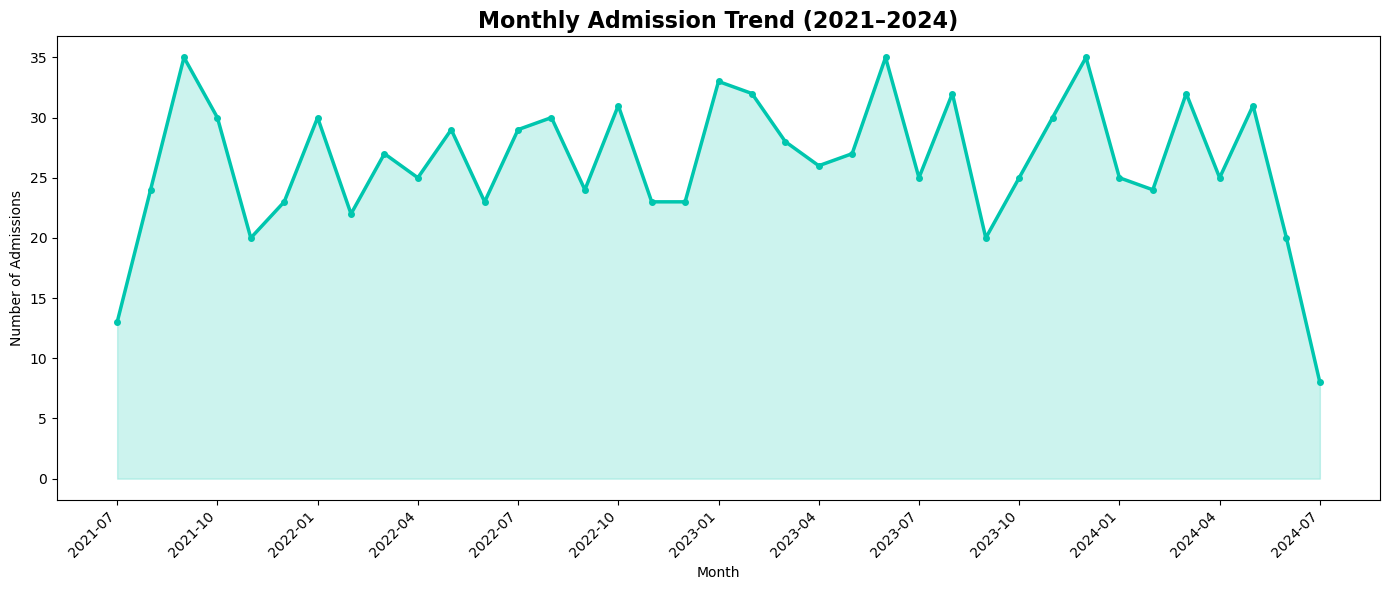

Insight: Peak month: 2021-09 with 35 admissions


In [46]:
# Monthly Admission Trend (2021–2024)
df['Admit Date'] = pd.to_datetime(df['Admit Date'])
monthly = df.groupby(df['Admit Date'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly.index, monthly.values, color='#00C6AE', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(monthly.index, monthly.values, alpha=0.2, color='#00C6AE')
plt.xticks(monthly.index[::3], rotation=45, ha='right')
plt.title('Monthly Admission Trend (2021–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150)
plt.show()
print("Insight: Peak month:", monthly.idxmax(), "with", monthly.max(), "admissions")

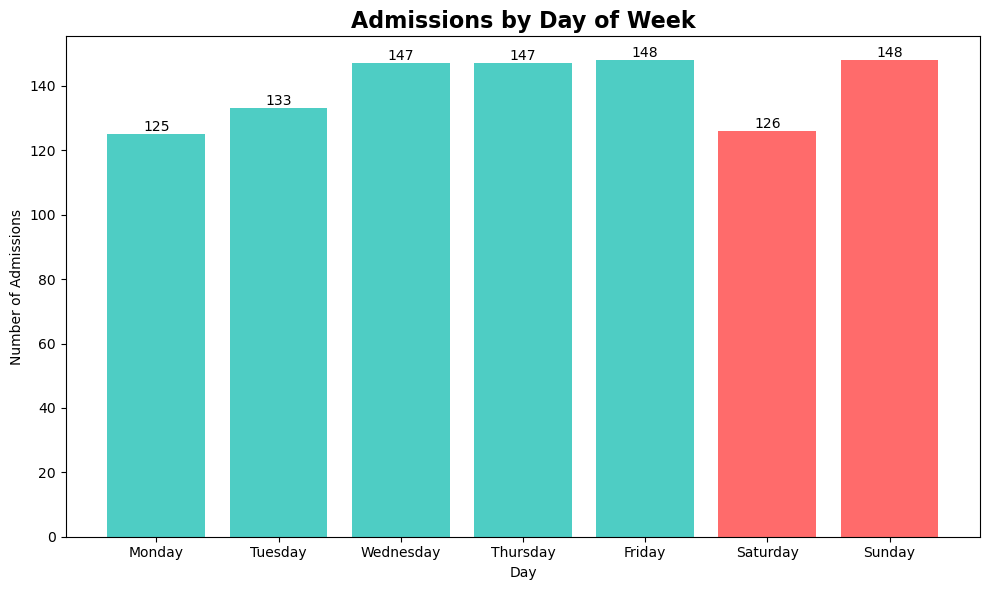

Insight: Weekday vs Weekend admissions:
Weekday: 700
Weekend: 274


In [47]:
# Admission by Day of Week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Admit Day of Week'].value_counts().sort_index()
day_counts.index = day_names

colors = ['#FF6B6B' if d in ['Saturday', 'Sunday'] else '#4ECDC4' for d in day_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(day_counts.index, day_counts.values, color=colors)
plt.title('Admissions by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Admissions')
for bar, val in zip(bars, day_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart3_day_of_week.png', dpi=150)
plt.show()
print("Insight: Weekday vs Weekend admissions:")
print("Weekday:", df[df['Is Weekend']==0].shape[0])
print("Weekend:", df[df['Is Weekend']==1].shape[0])

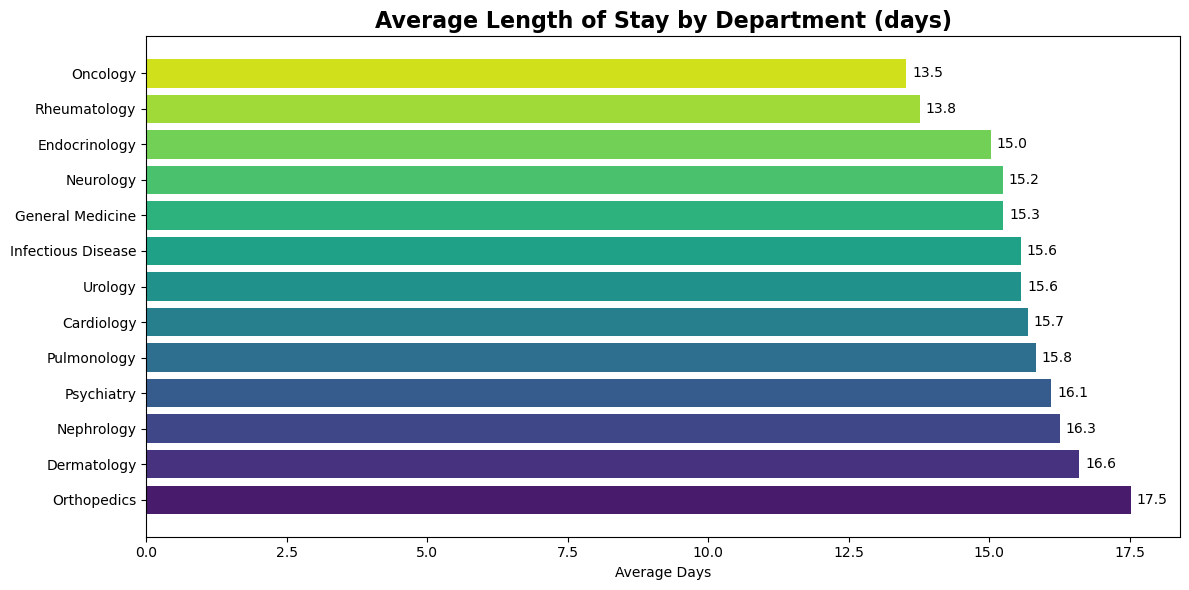

Insight: Longest avg stay: Orthopedics - 17.5 days


In [48]:
# Length of Stay by Department
los_dept = df.groupby('Department')['Length of Stay'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(los_dept.index, los_dept.values, color=sns.color_palette("viridis", len(los_dept)))
plt.title('Average Length of Stay by Department (days)', fontsize=16, fontweight='bold')
plt.xlabel('Average Days')
for bar, val in zip(bars, los_dept.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart4_los_by_dept.png', dpi=150)
plt.show()
print("Insight: Longest avg stay:", los_dept.index[0], "-", round(los_dept.values[0], 1), "days")

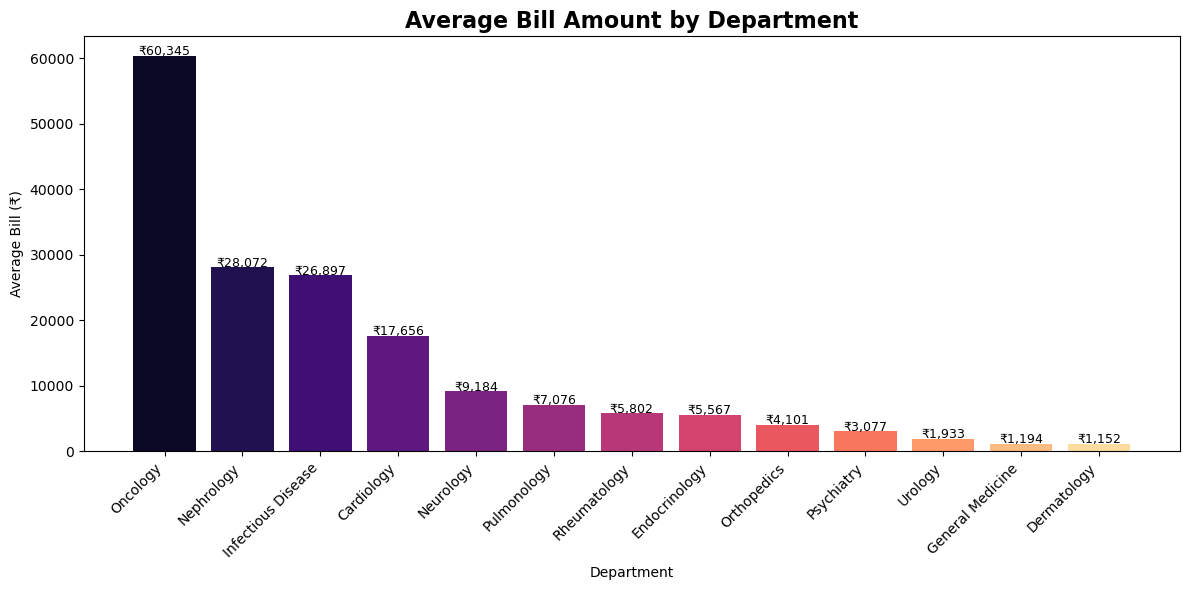

Insight: Most expensive dept: Oncology avg ₹ 60345.0


In [49]:
# Average Bill Amount by Department
bill_dept = df.groupby('Department')['Bill Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(bill_dept.index, bill_dept.values, color=sns.color_palette("magma", len(bill_dept)))
plt.xticks(rotation=45, ha='right')
plt.title('Average Bill Amount by Department', fontsize=16, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average Bill (₹)')
for bar, val in zip(bars, bill_dept.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'₹{val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_bill_by_dept.png', dpi=150)
plt.show()
print("Insight: Most expensive dept:", bill_dept.index[0], "avg ₹", round(bill_dept.values[0], 0))

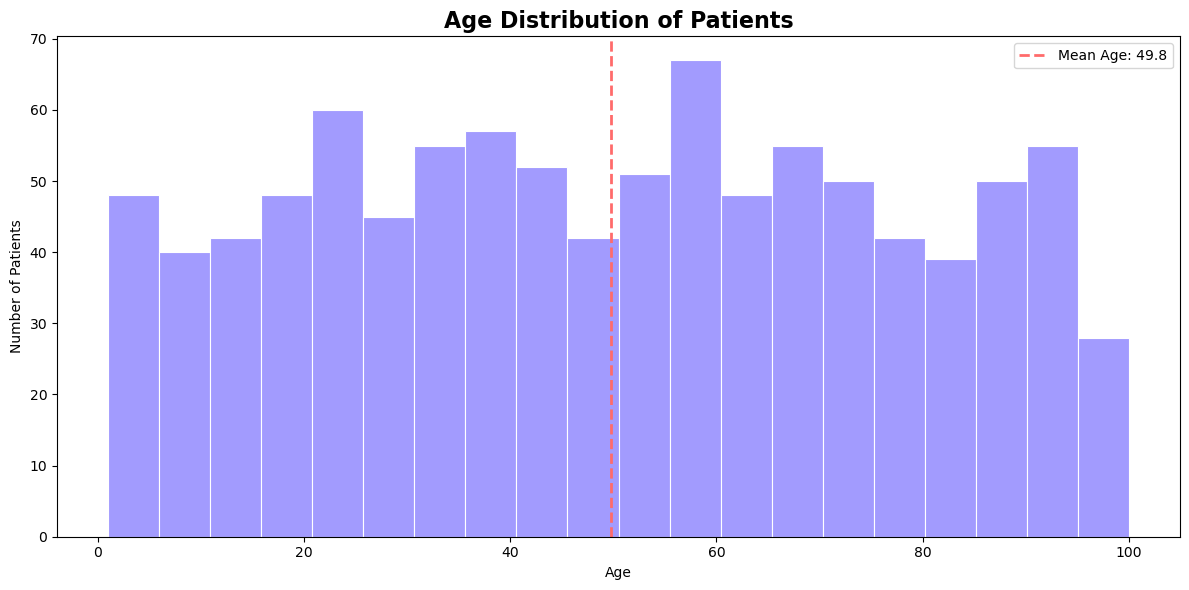

Insight: Average patient age: 49.8
Age group breakdown:
 Age Group
Elderly        319
Young Adult    181
Senior         166
Child          157
Middle Aged    151
Name: count, dtype: int64


In [50]:
# Age Distribution of Patients
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], bins=20, color='#A29BFE', edgecolor='white', linewidth=0.8)
plt.axvline(df['Age'].mean(), color='#FF6B6B', linewidth=2, linestyle='--', label=f"Mean Age: {df['Age'].mean():.1f}")
plt.title('Age Distribution of Patients', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_age_distribution.png', dpi=150)
plt.show()
print("Insight: Average patient age:", round(df['Age'].mean(), 1))
print("Age group breakdown:\n", df['Age Group'].value_counts())

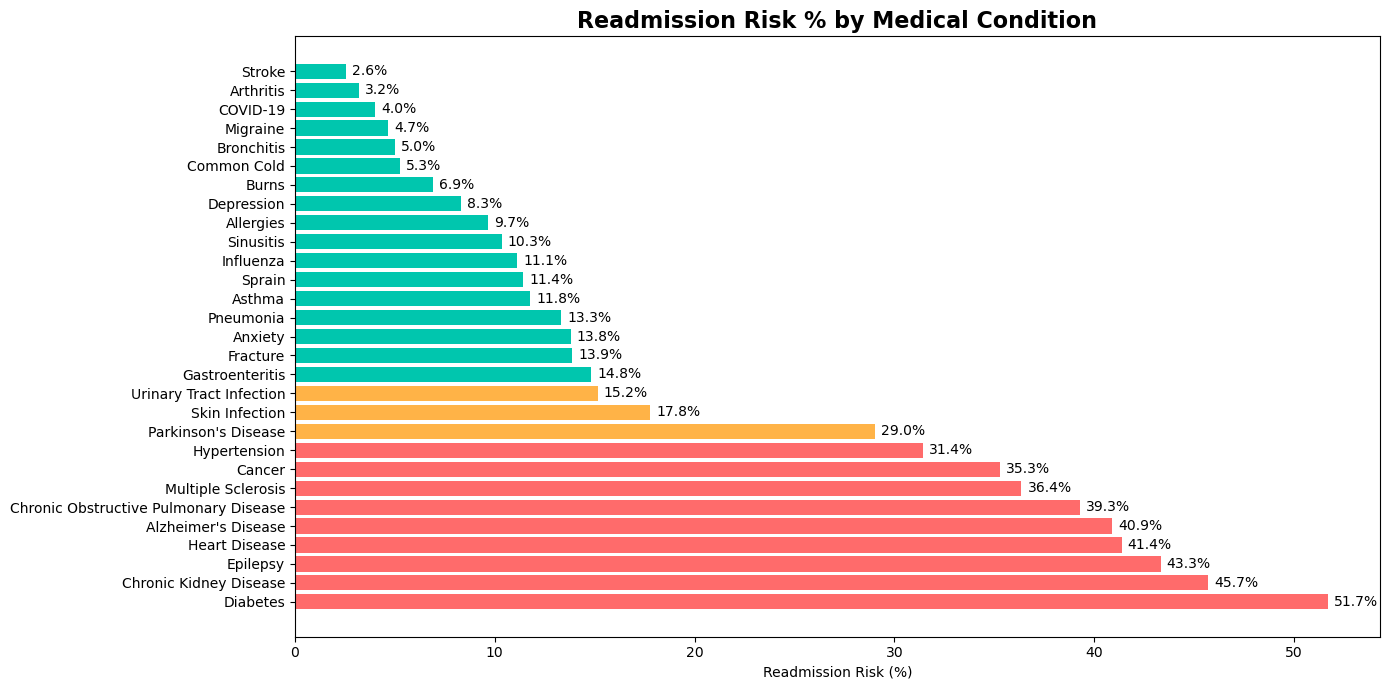

Insight: Highest risk condition: Diabetes - 51.7 %


In [51]:
# Readmission Risk by Medical Condition
readmit = df.groupby('Medical Condition')['Readmission Risk'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(14, 7))
bars = plt.barh(readmit.index, readmit.values,
                color=['#FF6B6B' if v > 30 else '#FFB347' if v > 15 else '#00C6AE' for v in readmit.values])
plt.title('Readmission Risk % by Medical Condition', fontsize=16, fontweight='bold')
plt.xlabel('Readmission Risk (%)')
for bar, val in zip(bars, readmit.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart7_readmission_risk.png', dpi=150)
plt.show()
print("Insight: Highest risk condition:", readmit.index[0], "-", round(readmit.values[0], 1), "%")

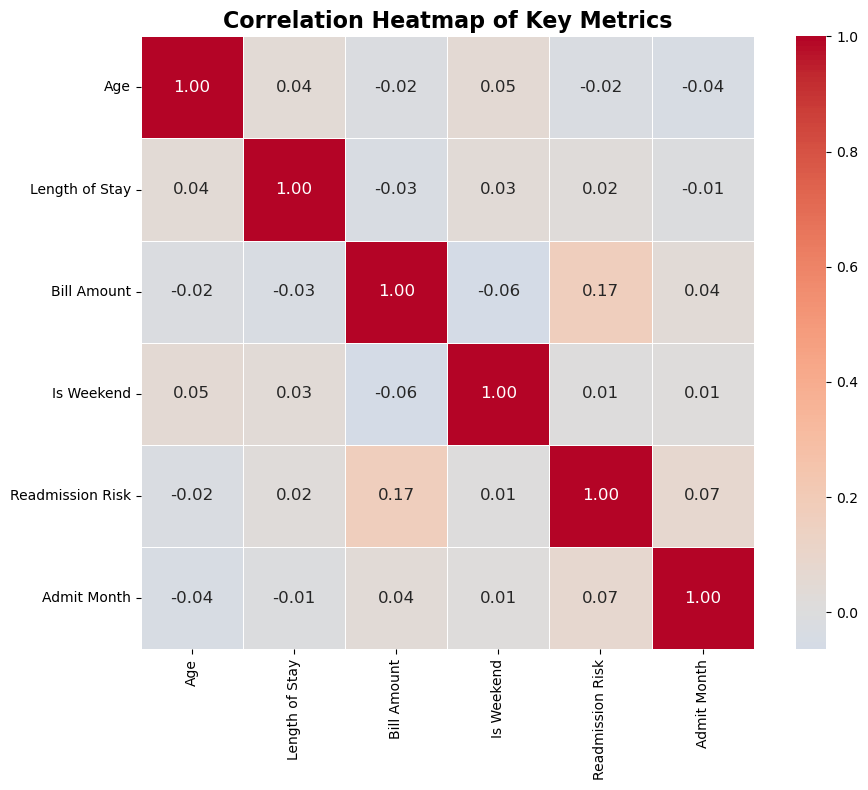

Insight: Strongest correlation: Readmission Risk → Bill Amount: 0.17


In [52]:
# Correlation Heatmap
numeric_cols = ['Age', 'Length of Stay', 'Bill Amount', 'Is Weekend', 'Readmission Risk', 'Admit Month']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 12})
plt.title('Correlation Heatmap of Key Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', dpi=150)
plt.show()
print("Insight: Strongest correlation:", corr['Bill Amount'].drop('Bill Amount').idxmax(),
      "→ Bill Amount:", round(corr['Bill Amount'].drop('Bill Amount').max(), 2))

# Modeling

# Forecasting Monthly Admissions

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv('hospital_clean.csv')
df['Admit Date'] = pd.to_datetime(df['Admit Date'])

In [54]:
monthly = df.groupby(df['Admit Date'].dt.to_period('M')).size().reset_index()
monthly.columns = ['Month', 'Admissions']
monthly['Month_Num'] = range(len(monthly))

In [55]:
X = monthly[['Month_Num']]
y = monthly['Admissions']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [57]:
# Forecaste for next 6 months
future_months = pd.DataFrame({'Month_Num': range(len(monthly), len(monthly) + 6)})
forecast = model.predict(future_months)

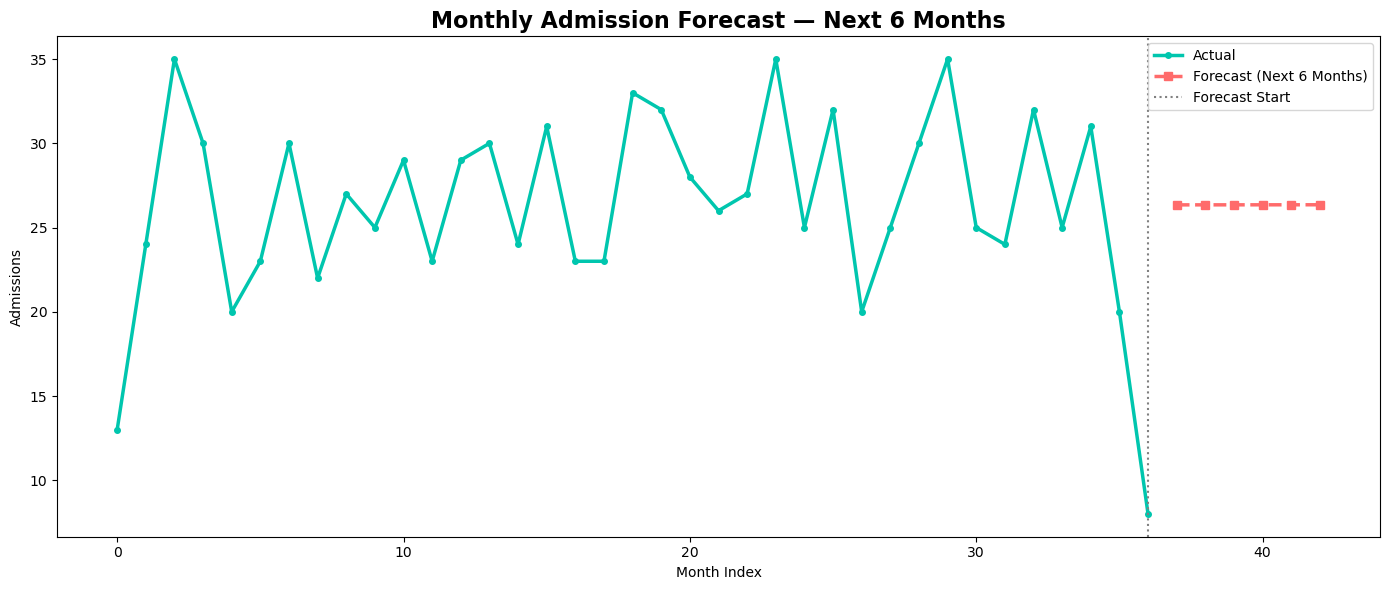

Forecasted admissions for next 6 months:
  Month +1: 26 admissions
  Month +2: 26 admissions
  Month +3: 26 admissions
  Month +4: 26 admissions
  Month +5: 26 admissions
  Month +6: 26 admissions


In [58]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(monthly['Month_Num'], monthly['Admissions'], 
         color='#00C6AE', linewidth=2.5, marker='o', markersize=4, label='Actual')
plt.plot(future_months['Month_Num'], forecast, 
         color='#FF6B6B', linewidth=2.5, marker='s', markersize=6, 
         linestyle='--', label='Forecast (Next 6 Months)')
plt.axvline(len(monthly) - 1, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('Monthly Admission Forecast — Next 6 Months', fontsize=16, fontweight='bold')
plt.xlabel('Month Index')
plt.ylabel('Admissions')
plt.legend()
plt.tight_layout()
plt.savefig('chart9_forecast.png', dpi=150)
plt.show()

print("Forecasted admissions for next 6 months:")
for i, val in enumerate(forecast, 1):
    print(f"  Month +{i}: {round(val)} admissions")

# Readmission Risk Classification

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [60]:
# Prepare features
features = ['Age', 'Length of Stay', 'Bill Amount', 'Is Weekend', 'Admit Month']
target = 'Readmission Risk'

In [62]:
# Encode gender
df['Gender_Encoded'] = (df['Gender'] == 'Female').astype(int)
features.append('Gender_Encoded')
X = df[features]
y = df[target]

In [63]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
# Evaluate
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("TRACK B — READMISSION RISK MODEL RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", round(roc_auc_score(y_test, y_prob), 3))

TRACK B — READMISSION RISK MODEL RESULTS
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       157
           1       0.75      0.08      0.14        38

    accuracy                           0.82       195
   macro avg       0.78      0.54      0.52       195
weighted avg       0.80      0.82      0.75       195

AUC-ROC Score: 0.604


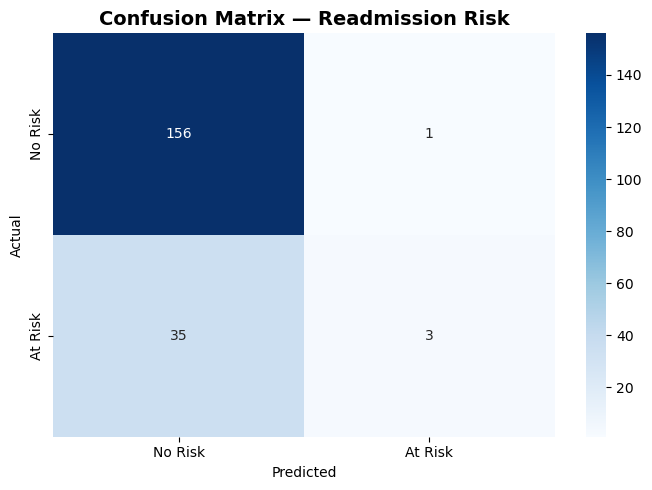

In [66]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk', 'At Risk'],
            yticklabels=['No Risk', 'At Risk'])
plt.title('Confusion Matrix — Readmission Risk', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart10_confusion_matrix.png', dpi=150)
plt.show()

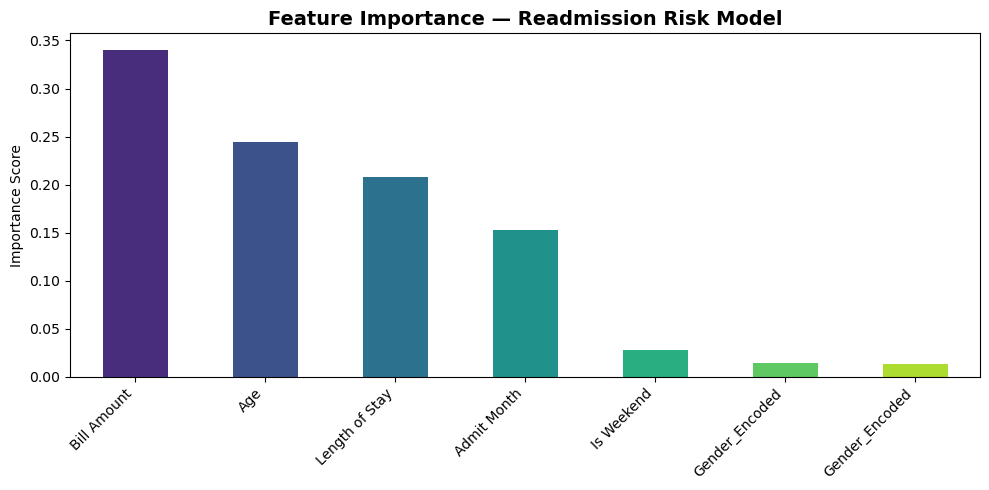

In [67]:
# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color=sns.color_palette("viridis", len(features)))
plt.title('Feature Importance — Readmission Risk Model', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart11_feature_importance.png', dpi=150)
plt.show()

In [68]:
print("\nTop predictor of readmission:", feat_imp.index[0])


Top predictor of readmission: Bill Amount


# Department Clustering

In [70]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [71]:
# Build department profile
dept_profile = df.groupby('Department').agg(
    Avg_LOS=('Length of Stay', 'mean'),
    Avg_Bill=('Bill Amount', 'mean'),
    Total_Admissions=('Patient ID', 'count'),
    Readmission_Rate=('Readmission Risk', 'mean'),
    Avg_Age=('Age', 'mean')
).reset_index()

print("Department Profiles:\n", dept_profile)

Department Profiles:
             Department    Avg_LOS      Avg_Bill  Total_Admissions  \
0           Cardiology  15.689320  17655.809903               103   
1          Dermatology  16.608108   1152.135000                74   
2        Endocrinology  15.034483   5566.869655                29   
3     General Medicine  15.254658   1193.910745               161   
4   Infectious Disease  15.560000  26896.732000                25   
5           Nephrology  16.257143  28071.950286                35   
6            Neurology  15.248619   9184.215801               181   
7             Oncology  13.529412  60345.114412                34   
8          Orthopedics  17.521127   4101.237606                71   
9           Psychiatry  16.107692   3077.321692                65   
10         Pulmonology  15.825758   7076.162955               132   
11        Rheumatology  13.774194   5802.325484                31   
12             Urology  15.575758   1932.785152                33   

    Readmis

In [72]:
# Scale features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(dept_profile[['Avg_LOS', 'Avg_Bill', 
                                                 'Total_Admissions', 'Readmission_Rate']])

In [73]:
# Find best K using elbow method
inertias = []
silhouettes = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

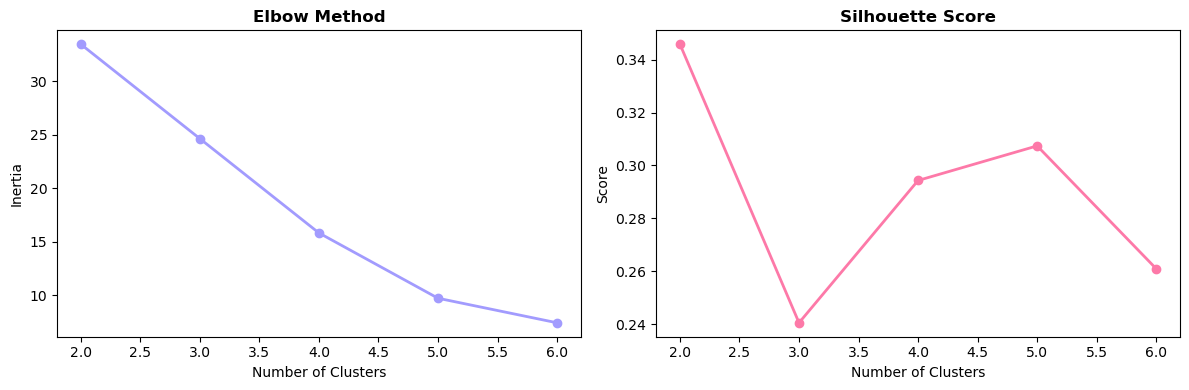

In [74]:
# Elbow plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', color='#A29BFE', linewidth=2)
plt.title('Elbow Method', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', color='#FD79A8', linewidth=2)
plt.title('Silhouette Score', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('chart12_elbow.png', dpi=150)
plt.show()

In [75]:
# Apply best K (usually 3)
best_k = K_range[silhouettes.index(max(silhouettes))]
print("Best number of clusters:", best_k)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
dept_profile['Cluster'] = km_final.fit_predict(X_cluster)

Best number of clusters: 2


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


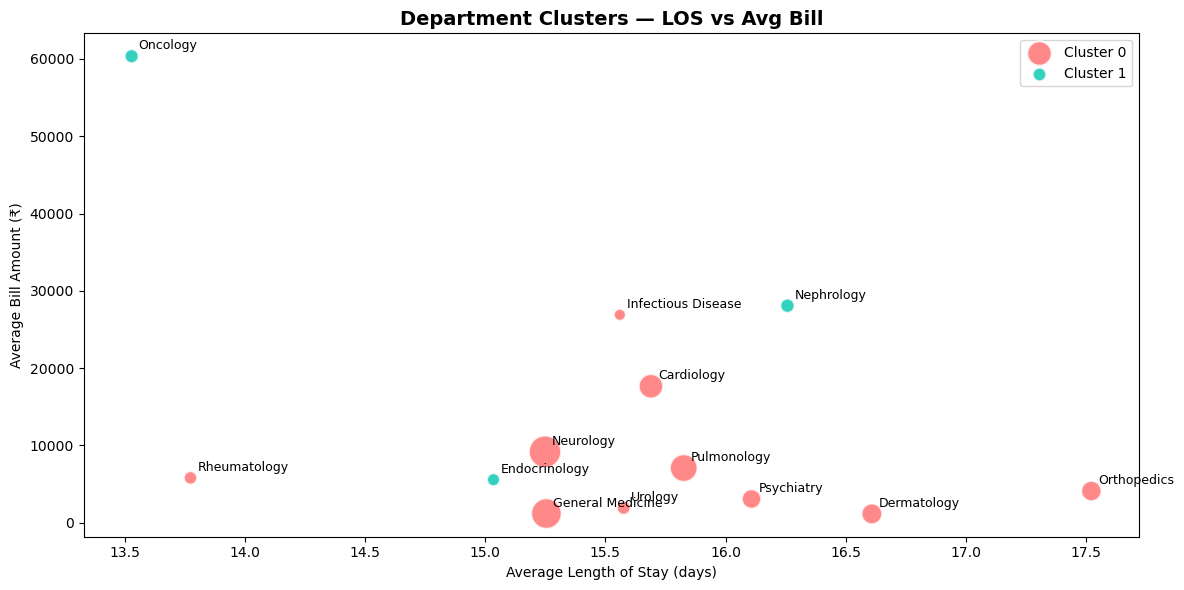


Department Cluster Assignments:
            Department  Cluster    Avg_LOS      Avg_Bill  Total_Admissions
0           Cardiology        0  15.689320  17655.809903               103
1          Dermatology        0  16.608108   1152.135000                74
3     General Medicine        0  15.254658   1193.910745               161
4   Infectious Disease        0  15.560000  26896.732000                25
6            Neurology        0  15.248619   9184.215801               181
10         Pulmonology        0  15.825758   7076.162955               132
9           Psychiatry        0  16.107692   3077.321692                65
8          Orthopedics        0  17.521127   4101.237606                71
12             Urology        0  15.575758   1932.785152                33
11        Rheumatology        0  13.774194   5802.325484                31
2        Endocrinology        1  15.034483   5566.869655                29
5           Nephrology        1  16.257143  28071.950286           

In [76]:
# Visualize clusters
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#00C6AE', '#A29BFE', '#FDCB6E']
for cluster in range(best_k):
    subset = dept_profile[dept_profile['Cluster'] == cluster]
    plt.scatter(subset['Avg_LOS'], subset['Avg_Bill'],
                s=subset['Total_Admissions'] * 3,
                color=colors[cluster], label=f'Cluster {cluster}',
                alpha=0.8, edgecolors='white', linewidth=1.5)
    for _, row in subset.iterrows():
        plt.annotate(row['Department'], 
                     (row['Avg_LOS'], row['Avg_Bill']),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.title('Department Clusters — LOS vs Avg Bill', fontsize=14, fontweight='bold')
plt.xlabel('Average Length of Stay (days)')
plt.ylabel('Average Bill Amount (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('chart13_clusters.png', dpi=150)
plt.show()

print("\nDepartment Cluster Assignments:")
print(dept_profile[['Department', 'Cluster', 'Avg_LOS', 
                      'Avg_Bill', 'Total_Admissions']].sort_values('Cluster'))

In [79]:
import pandas as pd

df = pd.read_csv('hospital_clean.csv')

# Main patient data
df.to_csv('powerbi_patients.csv', index=False)

# Department summary
dept_summary = df.groupby('Department').agg(
    Total_Admissions=('Patient ID', 'count'),
    Avg_LOS=('Length of Stay', 'mean'),
    Avg_Bill=('Bill Amount', 'mean'),
    Readmission_Rate=('Readmission Risk', 'mean'),
    Avg_Age=('Age', 'mean')
).reset_index()
dept_summary.to_csv('powerbi_dept_summary.csv', index=False)

df['Admit Date'] = pd.to_datetime(df['Admit Date'])

# Monthly trend
monthly = df.groupby(df['Admit Date'].dt.to_period('M')).size().reset_index()
monthly.columns = ['Month', 'Admissions']
monthly['Month'] = monthly['Month'].astype(str)
monthly.to_csv('powerbi_monthly.csv', index=False)

# Medical condition summary
condition_summary = df.groupby('Medical Condition').agg(
    Total_Patients=('Patient ID', 'count'),
    Avg_Bill=('Bill Amount', 'mean'),
    Avg_LOS=('Length of Stay', 'mean'),
    Readmission_Rate=('Readmission Risk', 'mean')
).reset_index()
condition_summary.to_csv('powerbi_conditions.csv', index=False)

print("All 4 files exported successfully!")
print("Files created:")
print("  - powerbi_patients.csv")
print("  - powerbi_dept_summary.csv")
print("  - powerbi_monthly.csv")
print("  - powerbi_conditions.csv")

All 4 files exported successfully!
Files created:
  - powerbi_patients.csv
  - powerbi_dept_summary.csv
  - powerbi_monthly.csv
  - powerbi_conditions.csv


In [80]:
import os
print("Your files are saved here:")
print(os.getcwd())

Your files are saved here:
C:\Users\Akhil
